In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters
import os
import warnings
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner.tuners import RandomSearch
warnings.filterwarnings('ignore')

In [3]:
# Reading the training dataset
train_data = pd.read_csv('train.csv')

# Reading the test dataset
test_data = pd.read_csv('test.csv')

# Total dataset
total_data = train_data.shape[0] + test_data.shape[0]
print(f"Number of dataset in training datasets: {train_data.shape[0]} which is {round(100*train_data.shape[0]/total_data, 2)}% of total datasets.")
print(f"Number of dataset in test datasets: {test_data.shape[0]} which is {round(100*test_data.shape[0]/total_data, 2)}% of total datasets.")

# shape of dataset
print(f"shape of training datasets: {train_data.shape}")
print(f"shape of test datasets: {test_data.shape}")

Number of dataset in training datasets: 7352 which is 71.39% of total datasets.
Number of dataset in test datasets: 2947 which is 28.61% of total datasets.
shape of training datasets: (7352, 563)
shape of test datasets: (2947, 563)


In [4]:
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [5]:
train_data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


In [6]:
train_df = train_data
test_df = test_data

In [7]:
# Checking for nan
print("*********CHECKING NAN*********")
print(f"How many Nan values are present in training dataset? \nAns: {train_data.isna().values.sum()}")
print(f"How many Nan values are present in test dataset? \nAns: {test_data.isna().values.sum()}")
print()

# Checking for null
print("*********CHECKING NULL*********")
print(f"How many NULL values are present in training dataset? \nAns: {train_data.isnull().values.sum()}")
print(f"How many NULL values are present in test dataset? \nAns: {test_data.isnull().values.sum()}")
print()

# Checking for duplicates
print("*********CHECKING DUPLICATES*********")
print(f"How many duplicates data re present in training dataset? \nAns: {train_data.duplicated().values.sum()}")
print(f"How many duplicates data re present in test dataset? \nAns: {test_data.duplicated().values.sum()}")

*********CHECKING NAN*********
How many Nan values are present in training dataset? 
Ans: 0
How many Nan values are present in test dataset? 
Ans: 0

*********CHECKING NULL*********
How many NULL values are present in training dataset? 
Ans: 0
How many NULL values are present in test dataset? 
Ans: 0

*********CHECKING DUPLICATES*********
How many duplicates data re present in training dataset? 
Ans: 0
How many duplicates data re present in test dataset? 
Ans: 0


In [8]:
train_features = train_df.drop(["Activity", "subject"], axis=1)
test_features = test_df.drop(["Activity", "subject"], axis=1)

train_labels = train_df["Activity"].replace(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'],  [0, 1, 2, 3, 4, 5])
test_labels = test_df["Activity"].replace(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'],  [0, 1, 2, 3, 4, 5])

print(train_features.shape)
print(test_features.shape)

print(train_labels.shape)
print(test_labels.shape)

(7352, 561)
(2947, 561)
(7352,)
(2947,)


In [9]:
X_train = train_features
X_test = test_features

Y_train = train_labels
Y_test = test_labels

In [10]:
columns = train_df.columns
print(columns.shape)
columns

(563,)


Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)

In [11]:
mean_X = []
mean_Y = []
mean_Z = []
for i in columns:
    if "mean" in i:
        if "X" in i:
            mean_X.append(i)
        elif "Y" in i:
            mean_Y.append(i)
        elif "Z" in i:
            mean_Z.append(i)
        
print(mean_X)
print(mean_Y)
print(mean_Z)

['tBodyAcc-mean()-X', 'tGravityAcc-mean()-X', 'tBodyAccJerk-mean()-X', 'tBodyGyro-mean()-X', 'tBodyGyroJerk-mean()-X', 'fBodyAcc-mean()-X', 'fBodyAcc-meanFreq()-X', 'fBodyAccJerk-mean()-X', 'fBodyAccJerk-meanFreq()-X', 'fBodyGyro-mean()-X', 'fBodyGyro-meanFreq()-X']
['tBodyAcc-mean()-Y', 'tGravityAcc-mean()-Y', 'tBodyAccJerk-mean()-Y', 'tBodyGyro-mean()-Y', 'tBodyGyroJerk-mean()-Y', 'fBodyAcc-mean()-Y', 'fBodyAcc-meanFreq()-Y', 'fBodyAccJerk-mean()-Y', 'fBodyAccJerk-meanFreq()-Y', 'fBodyGyro-mean()-Y', 'fBodyGyro-meanFreq()-Y']
['tBodyAcc-mean()-Z', 'tGravityAcc-mean()-Z', 'tBodyAccJerk-mean()-Z', 'tBodyGyro-mean()-Z', 'tBodyGyroJerk-mean()-Z', 'fBodyAcc-mean()-Z', 'fBodyAcc-meanFreq()-Z', 'fBodyAccJerk-mean()-Z', 'fBodyAccJerk-meanFreq()-Z', 'fBodyGyro-mean()-Z', 'fBodyGyro-meanFreq()-Z']


In [12]:
min_X = []
min_Y = []
min_Z = []

for i in columns:
    if "min" in i:
        if "X" in i:
            min_X.append(i)
        elif "Y" in i:
            min_Y.append(i)
        elif "Z" in i:
            min_Z.append(i)
        
print(min_X)
print(min_Y)
print(min_Z)

['tBodyAcc-min()-X', 'tGravityAcc-min()-X', 'tBodyAccJerk-min()-X', 'tBodyGyro-min()-X', 'tBodyGyroJerk-min()-X', 'fBodyAcc-min()-X', 'fBodyAccJerk-min()-X', 'fBodyGyro-min()-X']
['tBodyAcc-min()-Y', 'tGravityAcc-min()-Y', 'tBodyAccJerk-min()-Y', 'tBodyGyro-min()-Y', 'tBodyGyroJerk-min()-Y', 'fBodyAcc-min()-Y', 'fBodyAccJerk-min()-Y', 'fBodyGyro-min()-Y']
['tBodyAcc-min()-Z', 'tGravityAcc-min()-Z', 'tBodyAccJerk-min()-Z', 'tBodyGyro-min()-Z', 'tBodyGyroJerk-min()-Z', 'fBodyAcc-min()-Z', 'fBodyAccJerk-min()-Z', 'fBodyGyro-min()-Z']


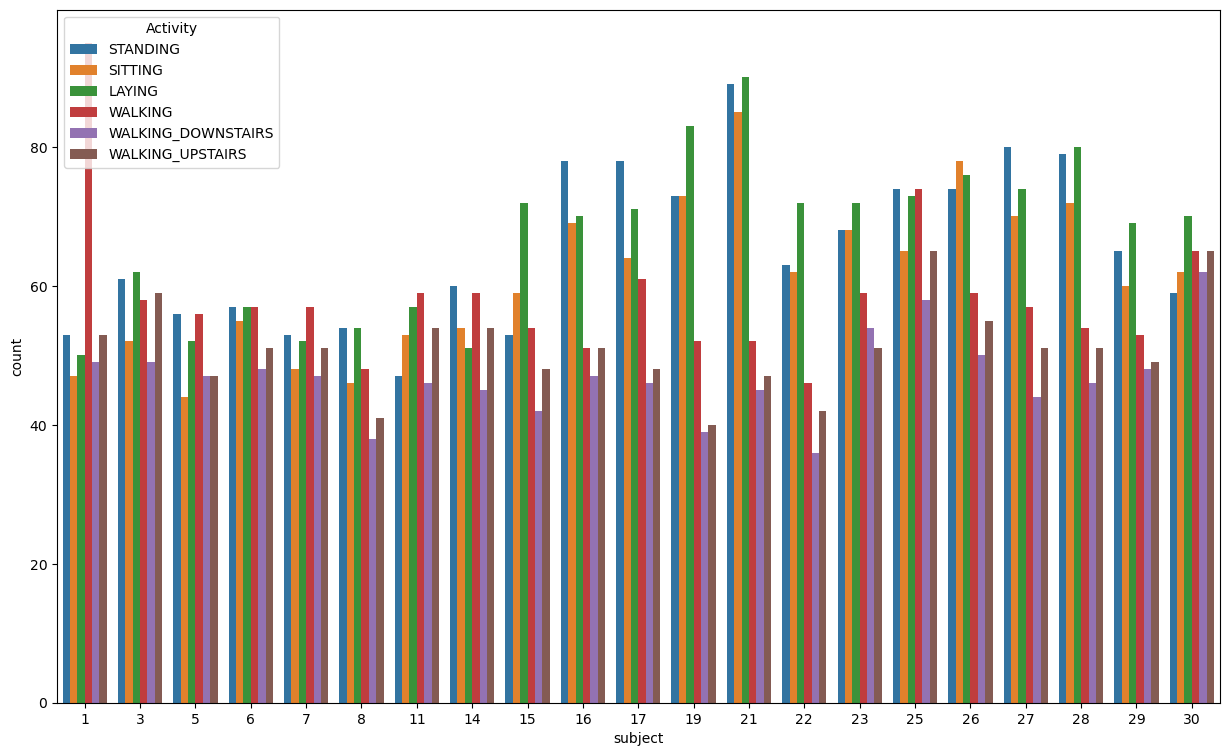

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,9))
sns.countplot(x='subject', hue='Activity', data=train_data)

plt.show()

<Axes: xlabel='Activity', ylabel='count'>

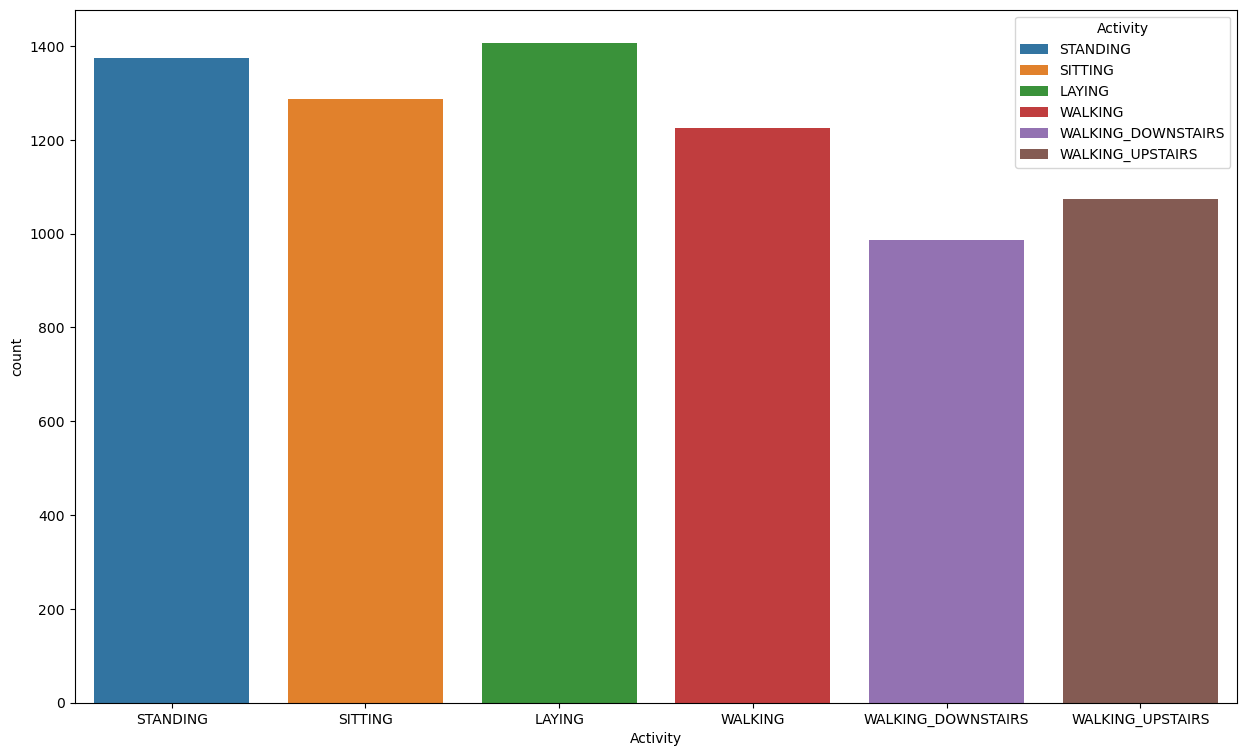

In [14]:
plt.figure(figsize=(15,9))
sns.countplot(x= "Activity", hue="Activity", data=train_data, dodge=False)
# plt.xticks(rotation=45)

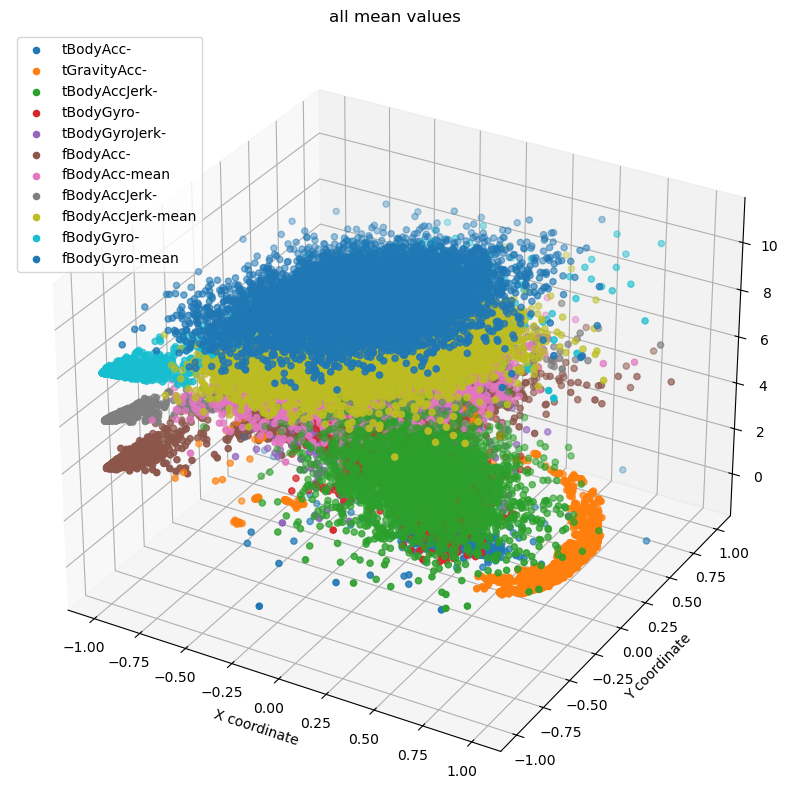

In [15]:
fig = plt.figure(figsize=(10, 10))
axs = plt.axes(projection="3d")

for i in range(len(mean_X)):
    axs.scatter(train_data[mean_X[i]].values, train_data[mean_Y[i]].values, train_data[mean_Z[i]].values+i, label=mean_X[i][0:-8])

plt.title("all mean values")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend(loc="upper left")
plt.show()


In [16]:
np.unique(train_df["Activity"])

array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

[Text(0, 0, 'LAYING'),
 Text(1, 0, 'SITTING'),
 Text(2, 0, 'STANDING'),
 Text(3, 0, 'WALKING'),
 Text(4, 0, 'WALKING_DOWNSTAIRS'),
 Text(5, 0, 'WALKING_UPSTAIRS')]

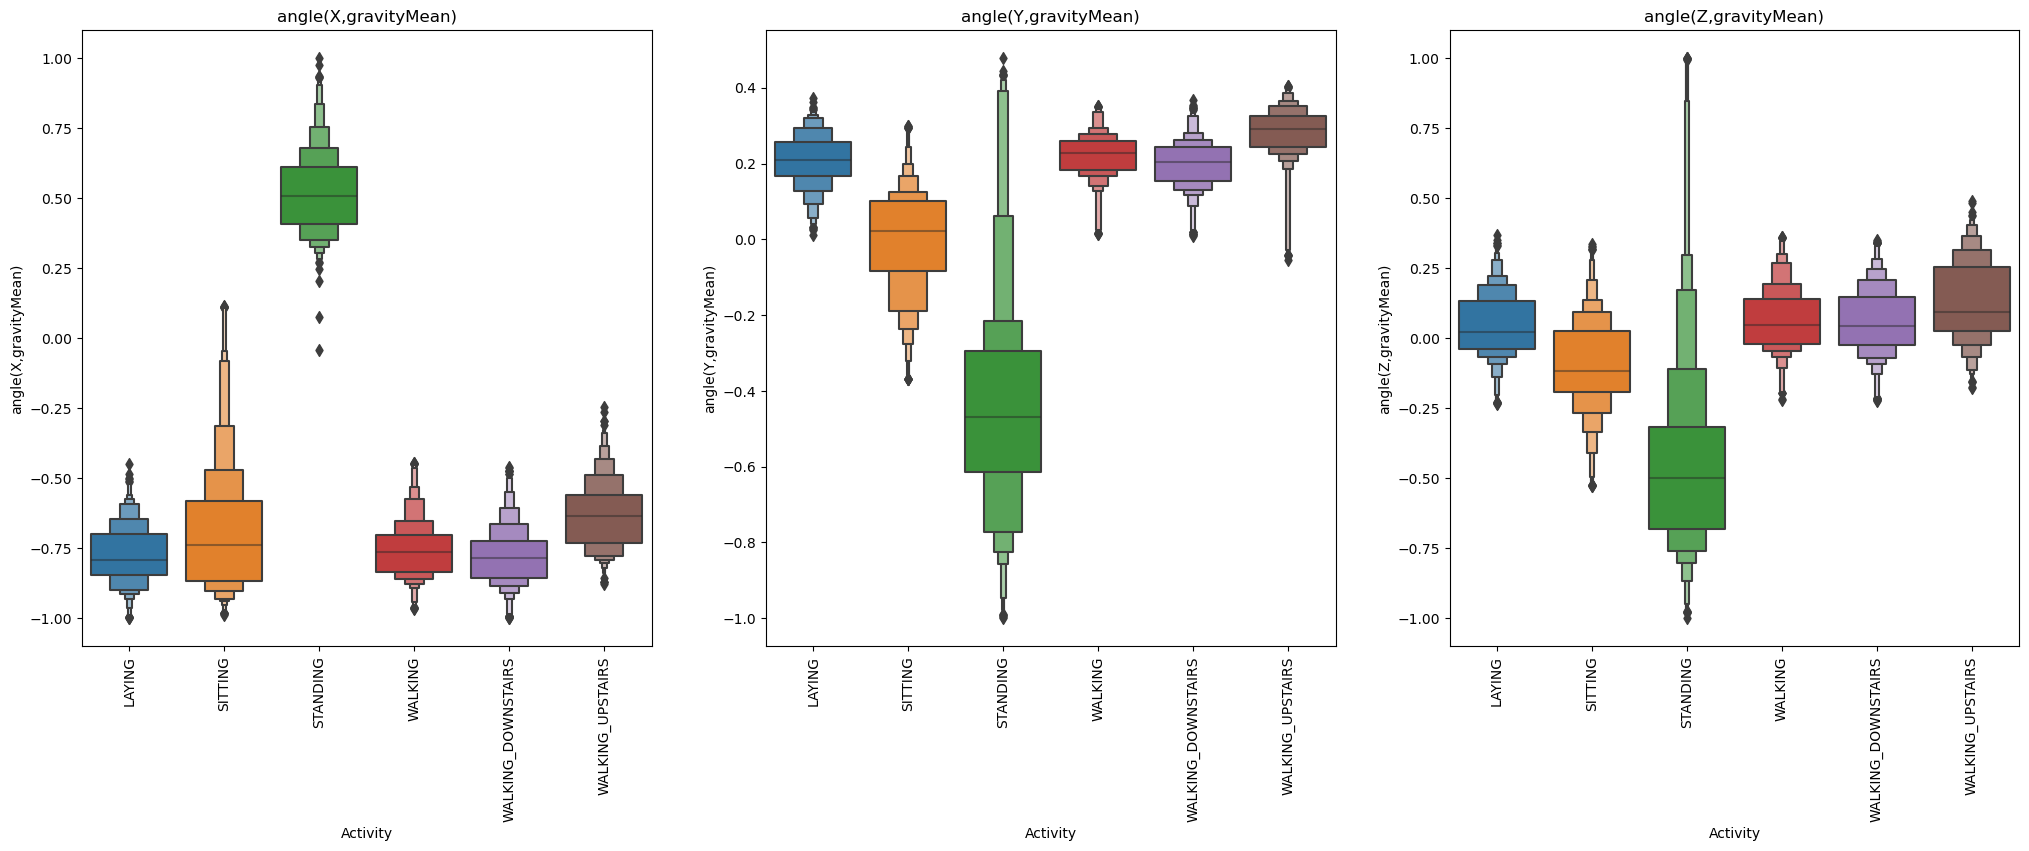

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(25, 8))
sns.boxenplot(ax = axs[0], x="Activity", y="angle(X,gravityMean)", data=train_df)
sns.boxenplot(ax = axs[1], x="Activity", y="angle(Y,gravityMean)", data=train_df)
sns.boxenplot(ax = axs[2], x="Activity", y="angle(Z,gravityMean)", data=train_df)

axs[0].set_title("angle(X,gravityMean)")
axs[0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], rotation="vertical")

axs[1].set_title("angle(Y,gravityMean)")
axs[1].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], rotation="vertical")

axs[2].set_title("angle(Z,gravityMean)")
axs[2].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], rotation="vertical")

In [18]:
min_X = []
min_Y = []
min_Z = []

mean_X = []
mean_Y = []
mean_Z = []

max_X = []
max_Y = []
max_Z = []

for i in columns:
    if "min" in i:
        if "X" in i:
            min_X.append(i)
            mean_X.append(i.replace("min", "mean"))
            max_X.append(i.replace("min", "max"))
        elif "Y" in i:
            min_Y.append(i)
            mean_Y.append(i.replace("min", "mean"))
            max_Y.append(i.replace("min", "mean"))
        elif "Z" in i:
            min_Z.append(i)
            mean_Z.append(i.replace("min", "mean"))
            max_Z.append(i.replace("min", "mean"))

        
print(min_X)
print(min_Y)
print(min_Z, "\n")

print(mean_X)
print(mean_Y)
print(mean_Z, "\n")

print(max_X)
print(max_Y)
print(max_Z, "\n")

['tBodyAcc-min()-X', 'tGravityAcc-min()-X', 'tBodyAccJerk-min()-X', 'tBodyGyro-min()-X', 'tBodyGyroJerk-min()-X', 'fBodyAcc-min()-X', 'fBodyAccJerk-min()-X', 'fBodyGyro-min()-X']
['tBodyAcc-min()-Y', 'tGravityAcc-min()-Y', 'tBodyAccJerk-min()-Y', 'tBodyGyro-min()-Y', 'tBodyGyroJerk-min()-Y', 'fBodyAcc-min()-Y', 'fBodyAccJerk-min()-Y', 'fBodyGyro-min()-Y']
['tBodyAcc-min()-Z', 'tGravityAcc-min()-Z', 'tBodyAccJerk-min()-Z', 'tBodyGyro-min()-Z', 'tBodyGyroJerk-min()-Z', 'fBodyAcc-min()-Z', 'fBodyAccJerk-min()-Z', 'fBodyGyro-min()-Z'] 

['tBodyAcc-mean()-X', 'tGravityAcc-mean()-X', 'tBodyAccJerk-mean()-X', 'tBodyGyro-mean()-X', 'tBodyGyroJerk-mean()-X', 'fBodyAcc-mean()-X', 'fBodyAccJerk-mean()-X', 'fBodyGyro-mean()-X']
['tBodyAcc-mean()-Y', 'tGravityAcc-mean()-Y', 'tBodyAccJerk-mean()-Y', 'tBodyGyro-mean()-Y', 'tBodyGyroJerk-mean()-Y', 'fBodyAcc-mean()-Y', 'fBodyAccJerk-mean()-Y', 'fBodyGyro-mean()-Y']
['tBodyAcc-mean()-Z', 'tGravityAcc-mean()-Z', 'tBodyAccJerk-mean()-Z', 'tBodyGyro-mean(

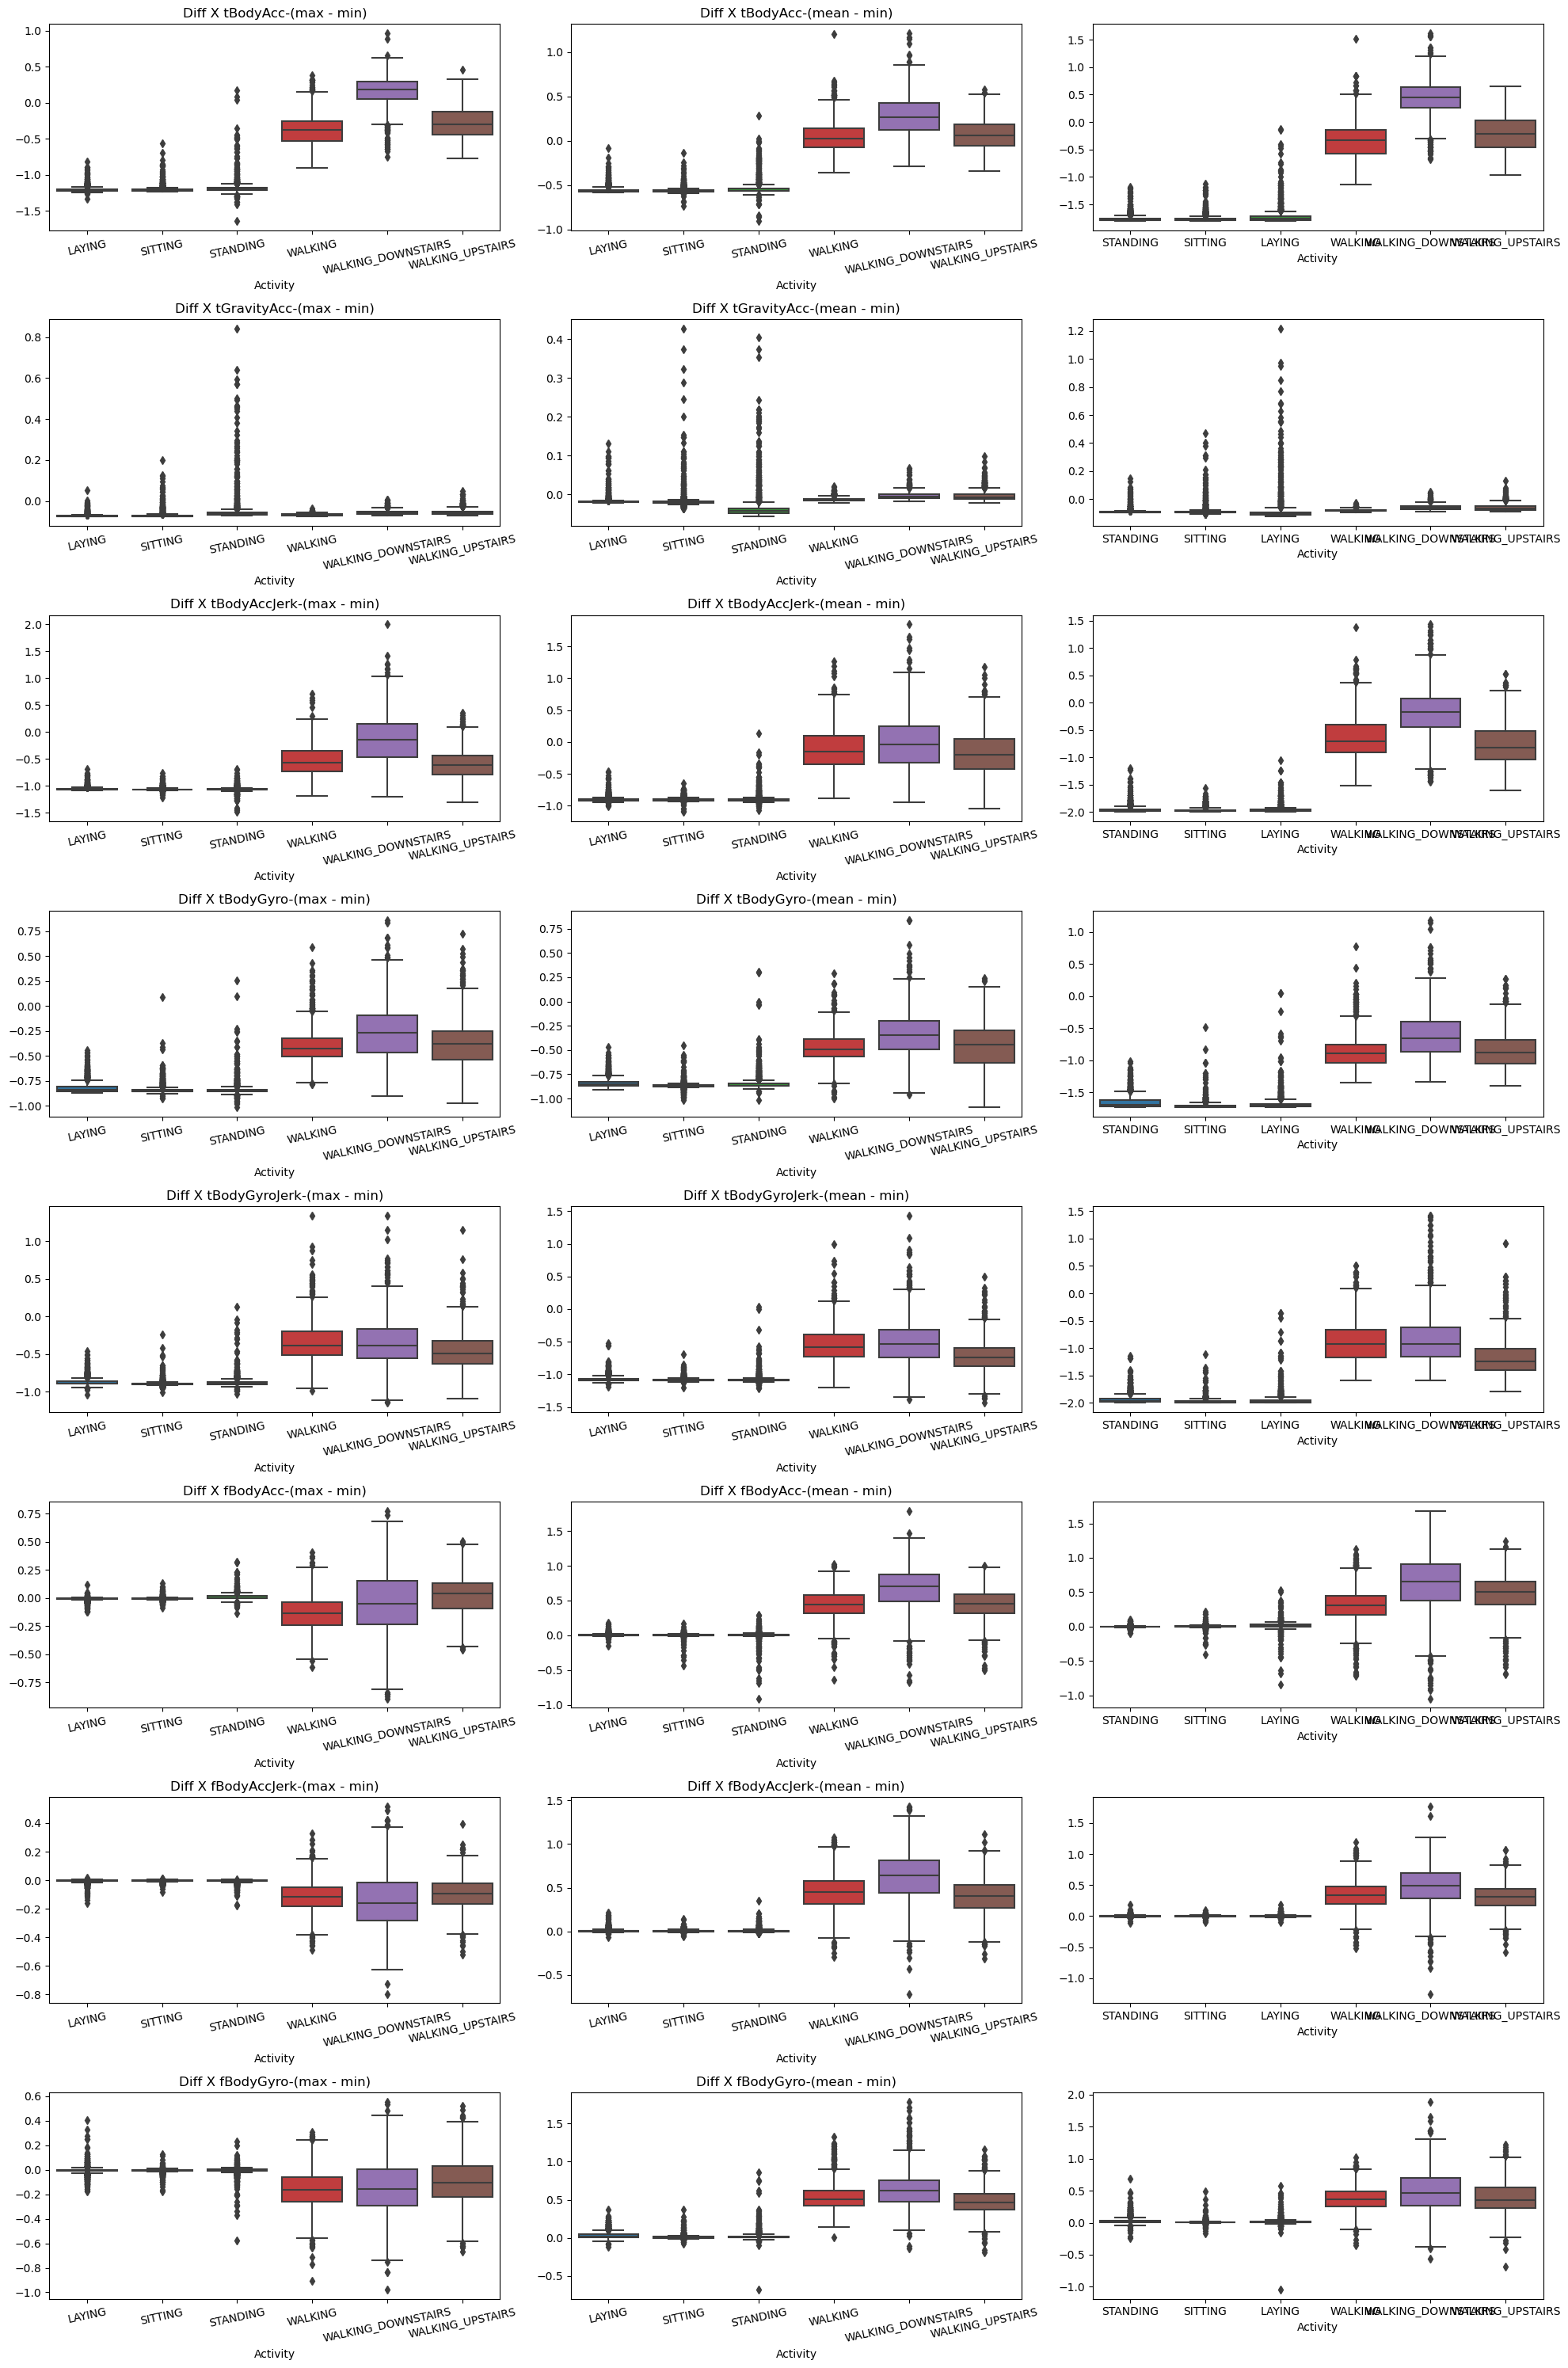

In [19]:
fig, axs = plt.subplots(len(min_X), 3, figsize=(20, 30))

for i in range(len(min_X)):
    mean_min_X = train_df[mean_X[i]] - train_df[min_X[i]]
    max_mean_X = train_df[max_X[i]] - train_df[mean_X[i]]
    max_min_X = train_df[max_X[i]] - train_df[min_X[i]]
    
#     mean_min_Y = train_df[mean_Y[i]] - train_df[min_Y[i]]
#     max_mean_Y = train_df[max_Y[i]] - train_df[mean_Y[i]]
#     max_min_Y = train_df[max_Y[i]] - train_df[min_Y[i]]
    
#     mean_min_Z = train_df[mean_Z[i]] - train_df[min_Z[i]]
#     max_mean_Z = train_df[max_Z[i]] - train_df[mean_Z[i]]
#     max_min_Z = train_df[max_Z[i]] - train_df[min_Z[i]]
    
    sns.boxplot(ax=axs[i, 0], x=train_df["Activity"], y=max_mean_X)
    sns.boxplot(ax=axs[i, 1], x=train_df["Activity"], y=mean_min_X)
    sns.boxplot(ax=axs[i, 2], x=train_df["Activity"], y=max_min_X)
    
    axs[i, 0].set_title("Diff X "+mean_X[i][0:-8]+"(max - mean)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)

    axs[i, 1].set_title("Diff X "+mean_X[i][0:-8]+"(mean - min)")
    axs[i, 1].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
    axs[i, 0].set_title("Diff X "+mean_X[i][0:-8]+"(max - min)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
plt.tight_layout()

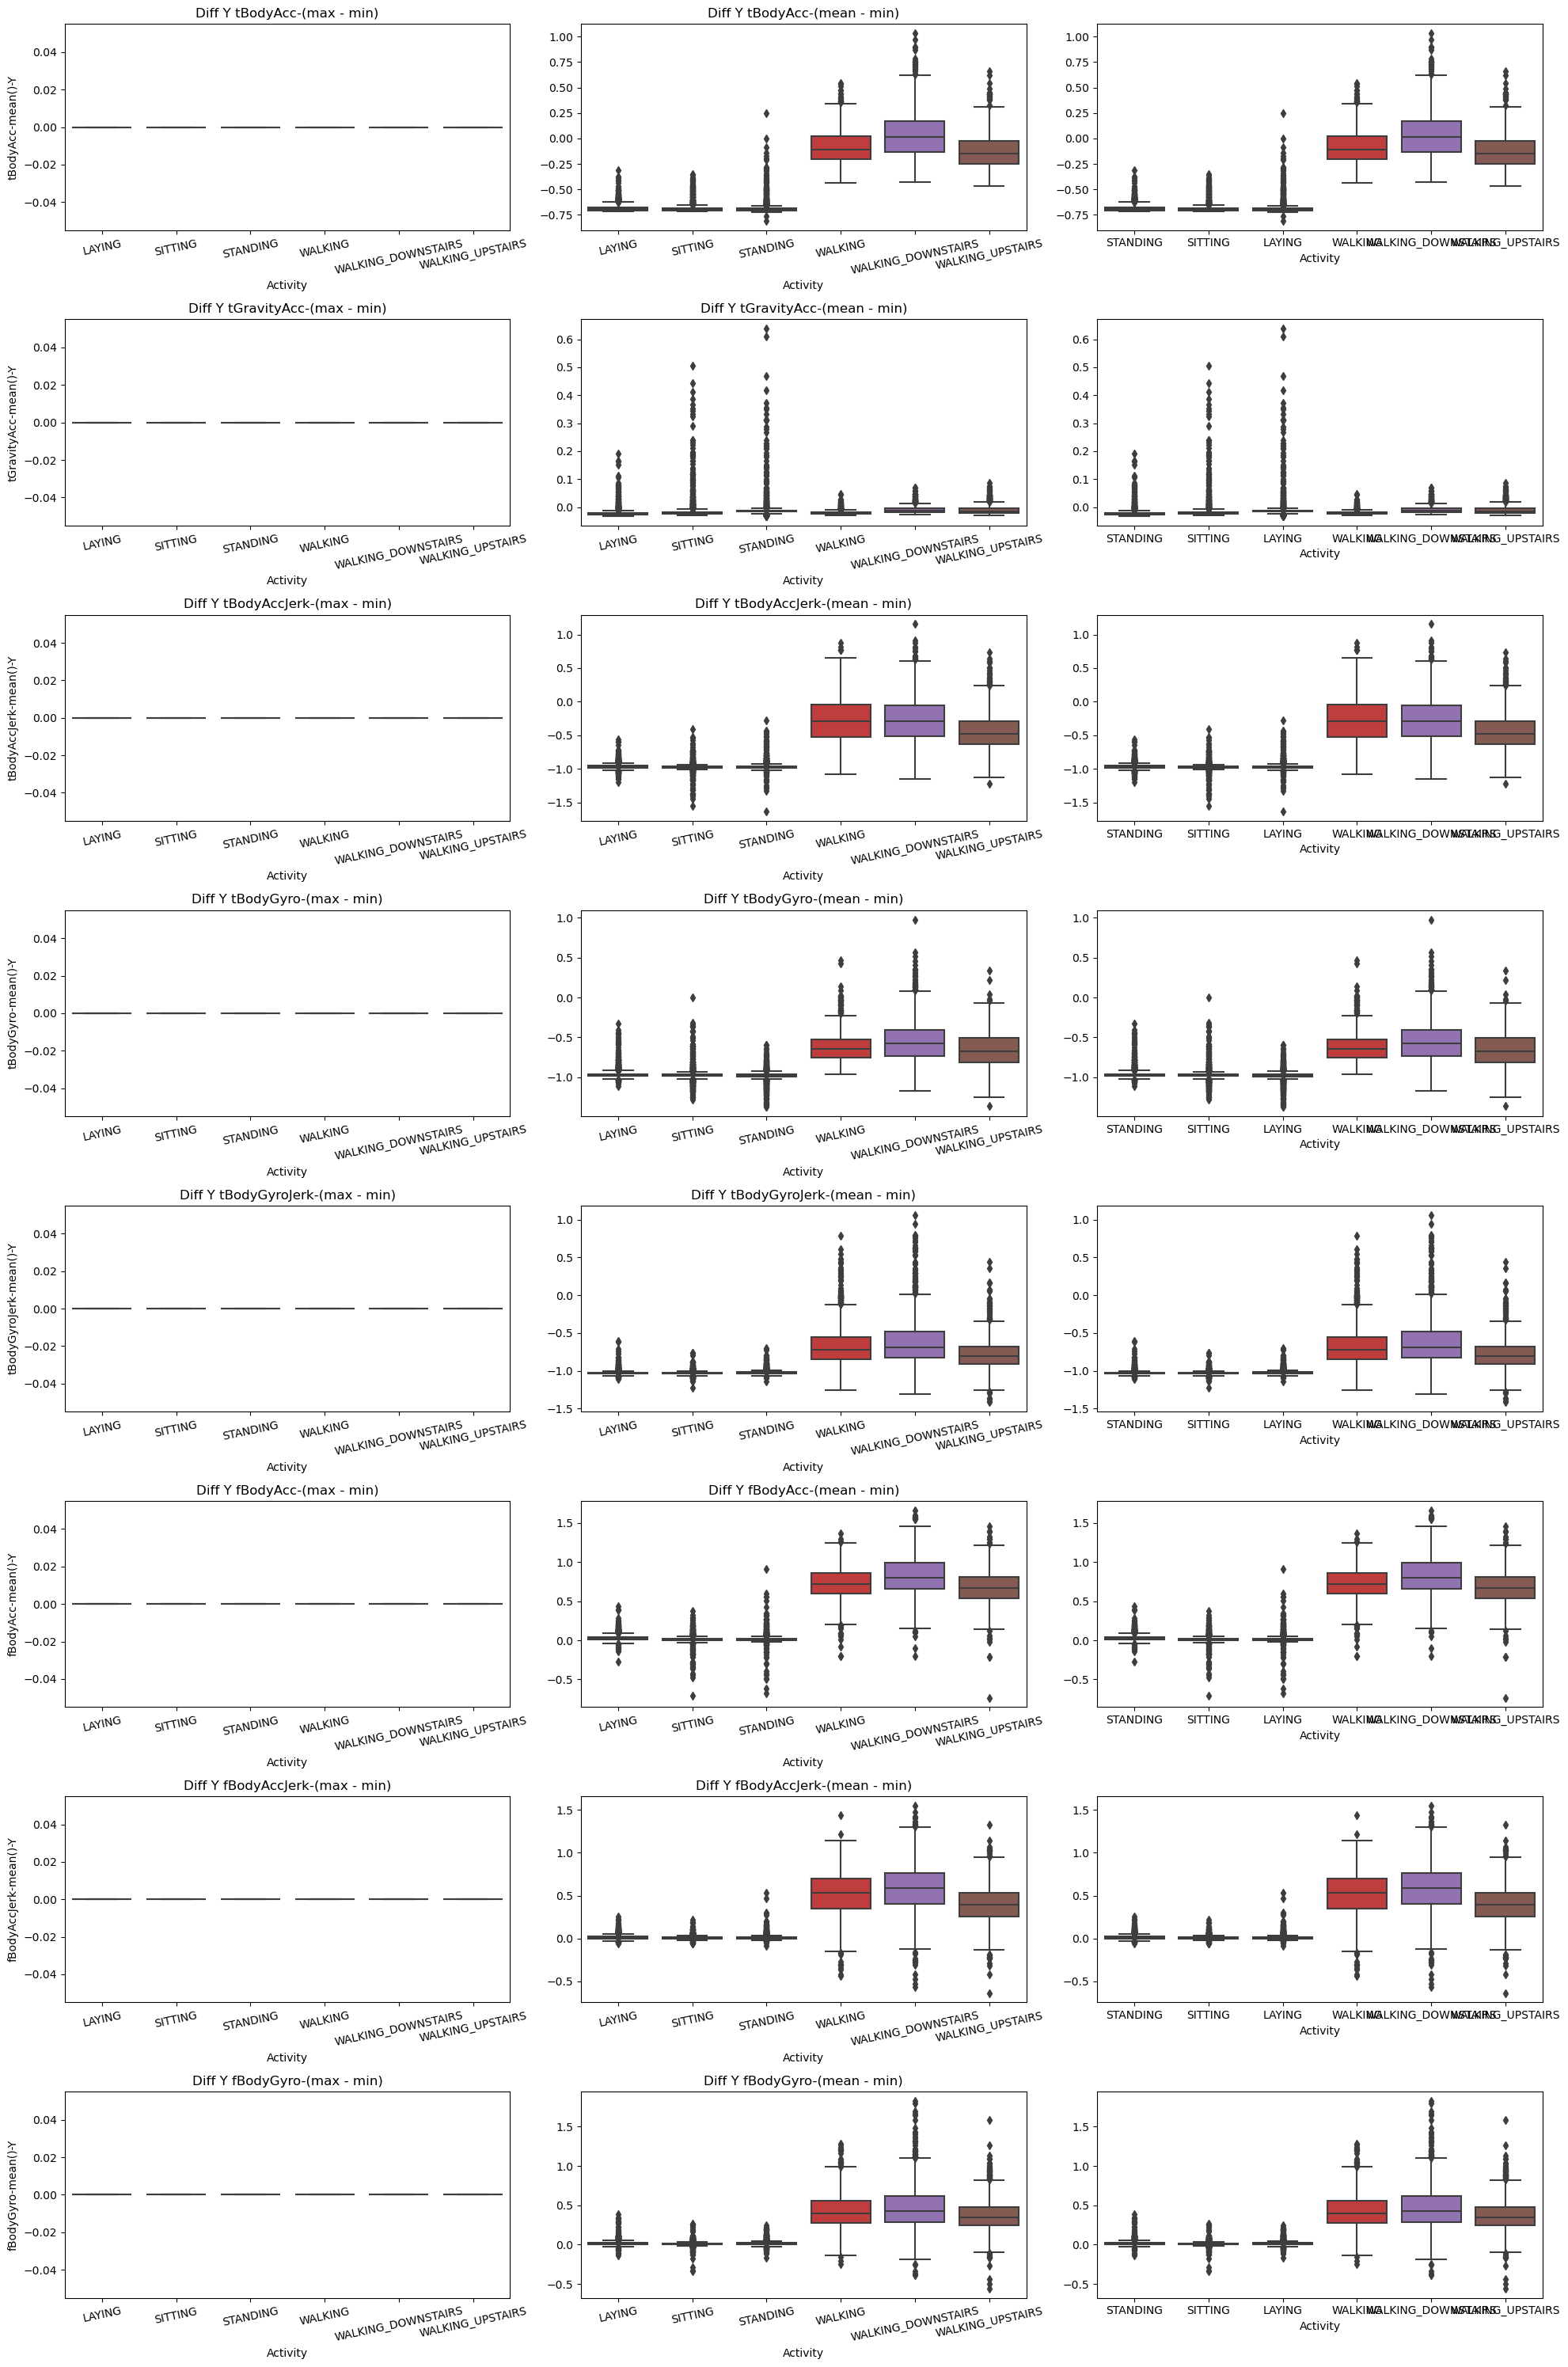

In [20]:
fig, axs = plt.subplots(len(min_X), 3, figsize=(20, 30))

for i in range(len(min_X)):
    
    mean_min_Y = train_df[mean_Y[i]] - train_df[min_Y[i]]
    max_mean_Y = train_df[max_Y[i]] - train_df[mean_Y[i]]
    max_min_Y = train_df[max_Y[i]] - train_df[min_Y[i]]
    
    sns.boxplot(ax=axs[i, 0], x=train_df["Activity"], y=max_mean_Y)
    sns.boxplot(ax=axs[i, 1], x=train_df["Activity"], y=mean_min_Y)
    sns.boxplot(ax=axs[i, 2], x=train_df["Activity"], y=max_min_Y)
    
    axs[i, 0].set_title("Diff Y "+mean_X[i][0:-8]+"(max - mean)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)

    axs[i, 1].set_title("Diff Y "+mean_X[i][0:-8]+"(mean - min)")
    axs[i, 1].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
    axs[i, 0].set_title("Diff Y "+mean_X[i][0:-8]+"(max - min)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
plt.tight_layout() 

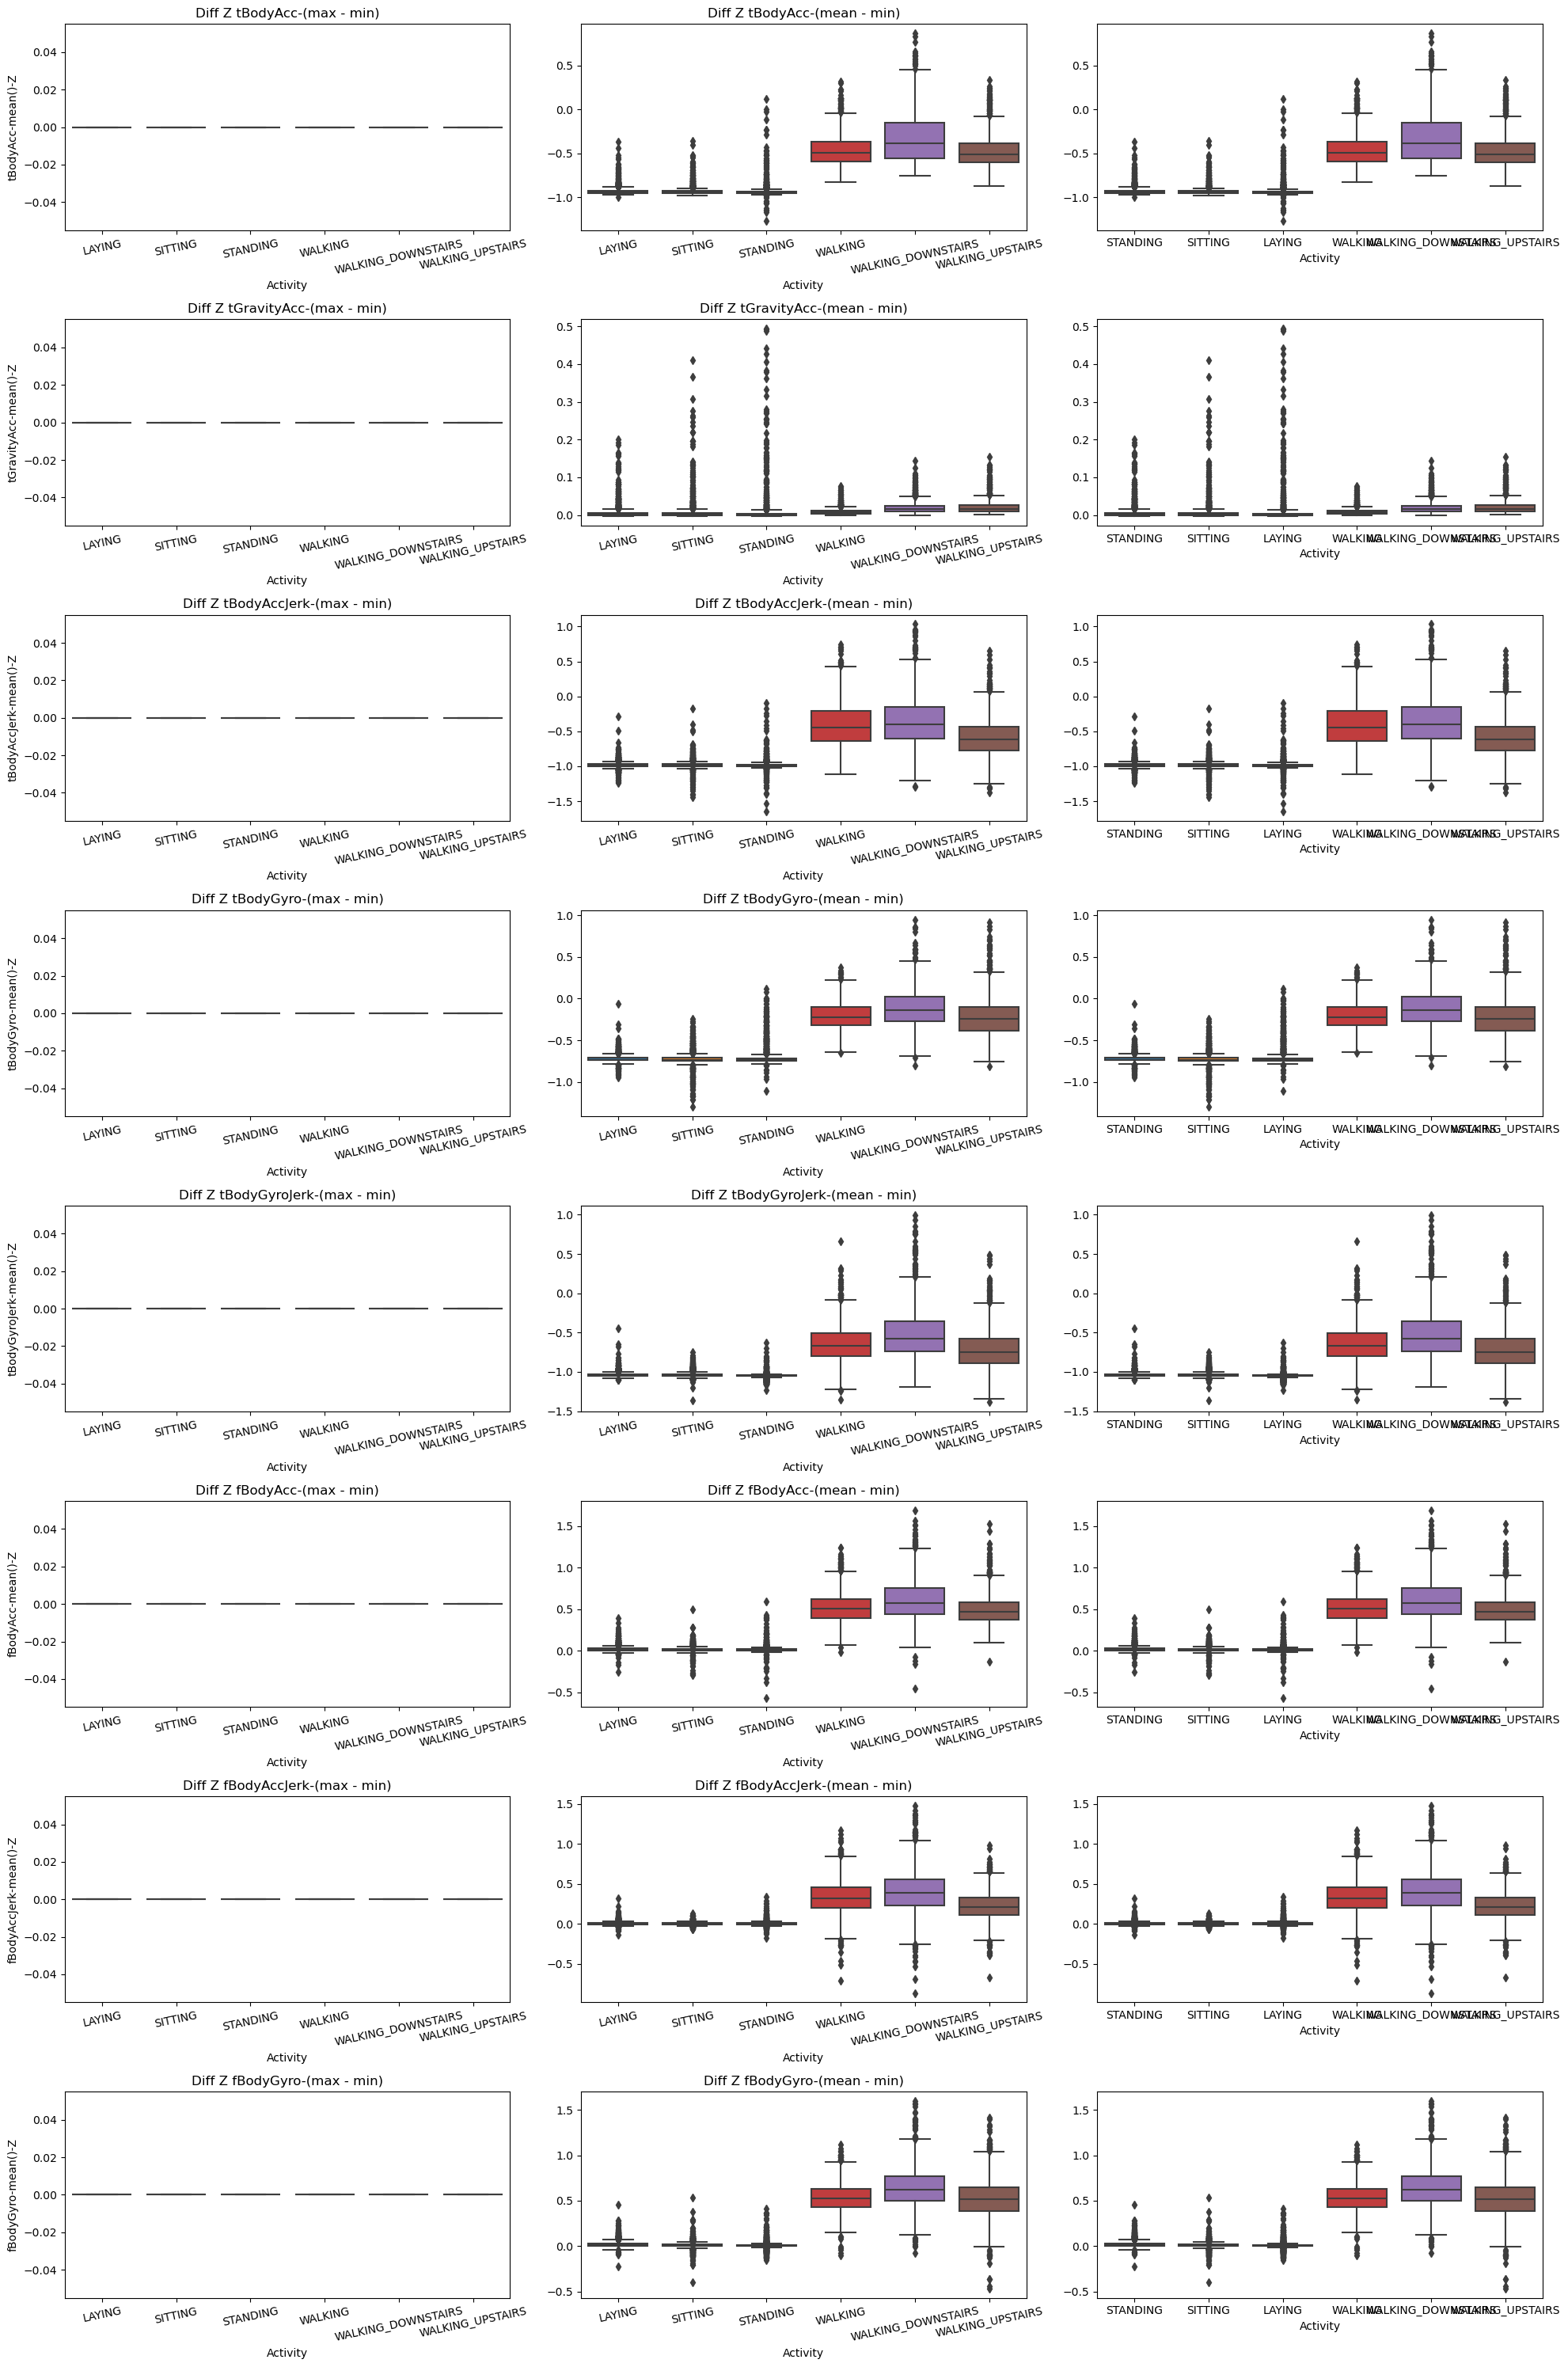

In [21]:
fig, axs = plt.subplots(len(min_X), 3, figsize=(20, 30))

for i in range(len(min_X)):
    
    mean_min_Z = train_df[mean_Z[i]] - train_df[min_Z[i]]
    max_mean_Z = train_df[max_Z[i]] - train_df[mean_Z[i]]
    max_min_Z = train_df[max_Z[i]] - train_df[min_Z[i]]
    
    sns.boxplot(ax=axs[i, 0], x=train_df["Activity"], y=max_mean_Z)
    sns.boxplot(ax=axs[i, 1], x=train_df["Activity"], y=mean_min_Z)
    sns.boxplot(ax=axs[i, 2], x=train_df["Activity"], y=max_min_Z)
    
    axs[i, 0].set_title("Diff Z "+mean_X[i][0:-8]+"(max - mean)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)

    axs[i, 1].set_title("Diff Z "+mean_X[i][0:-8]+"(mean - min)")
    axs[i, 1].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
    axs[i, 0].set_title("Diff Z "+mean_X[i][0:-8]+"(max - min)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
plt.tight_layout()

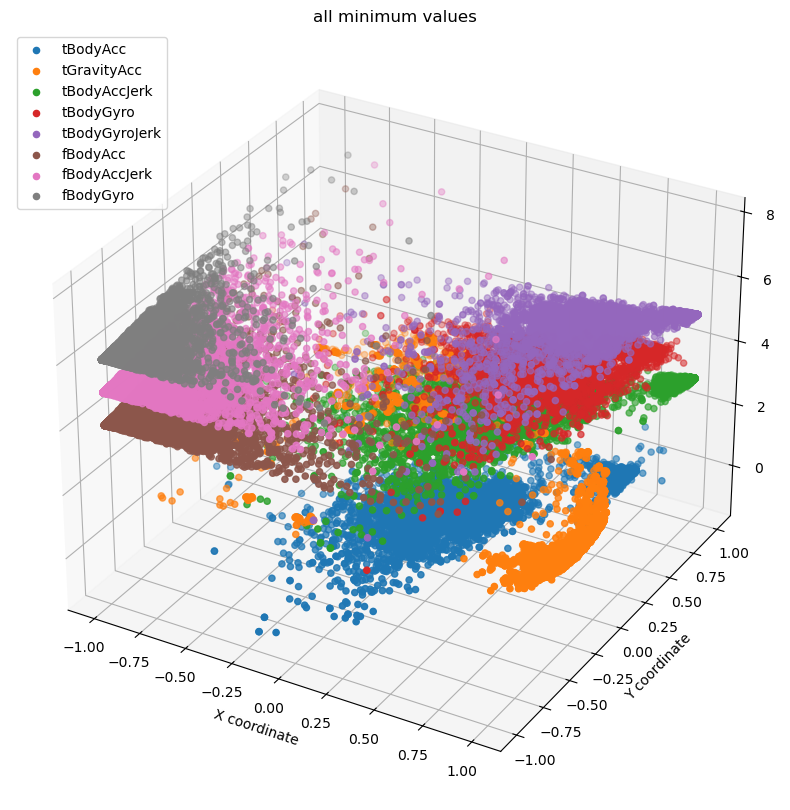

In [22]:
fig = plt.figure(figsize=(10, 10))
axs = plt.axes(projection="3d")

for i in range(len(min_X)):
    axs.scatter(train_df[min_X[i]].values, train_df[min_Y[i]].values, train_df[min_Y[i]].values+i, label=min_X[i][0:-8])

plt.title("all minimum values")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend(loc="upper left")
plt.show()

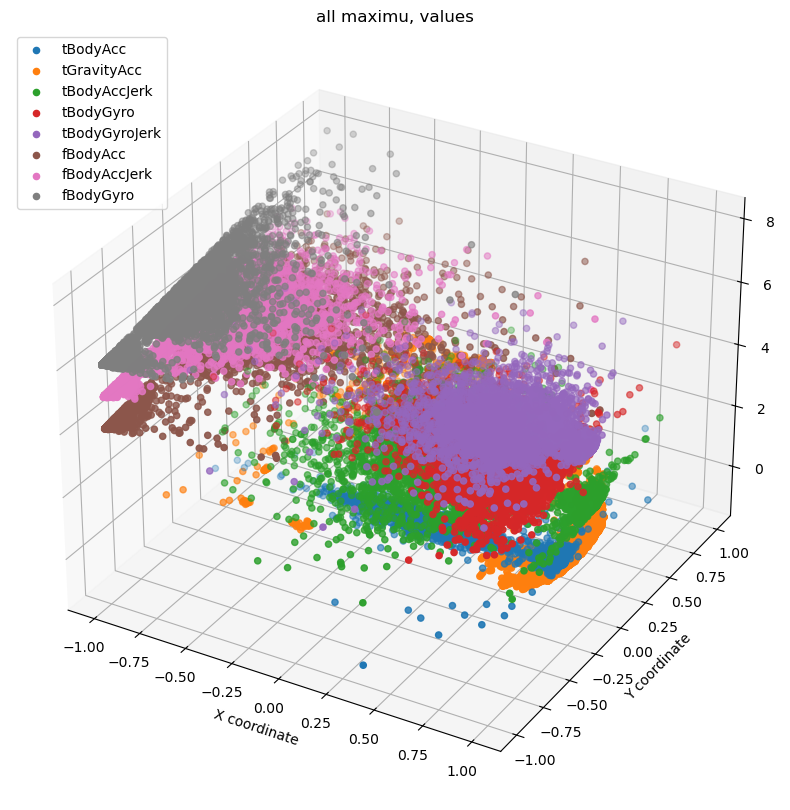

In [23]:
fig = plt.figure(figsize=(10, 10))
axs = plt.axes(projection="3d")

for i in range(len(max_X)):
    axs.scatter(train_df[min_X[i]].values, train_df[max_Y[i]].values, train_df[max_Y[i]].values+i, label=max_X[i][0:-8])

plt.title("all maximu, values")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend(loc="upper left")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


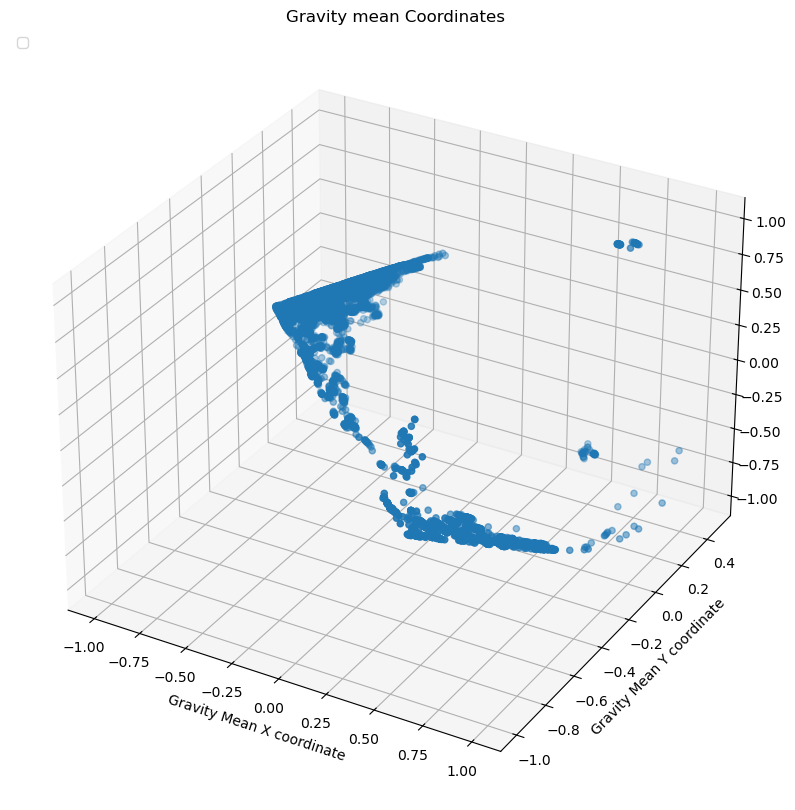

In [24]:
fig = plt.figure(figsize=(10, 10))
axs = plt.axes(projection="3d")

angle_X_gravityMean = train_df["angle(X,gravityMean)"].values
angle_Y_gravityMean = train_df["angle(Y,gravityMean)"].values
angle_Z_gravityMean = train_df["angle(Z,gravityMean)"].values

axs.scatter(angle_X_gravityMean, angle_Y_gravityMean, angle_Z_gravityMean)

plt.title("Gravity mean Coordinates")
plt.xlabel("Gravity Mean X coordinate")
plt.ylabel("Gravity Mean Y coordinate")
# plt.set_zlabel("Gravity Mean Z coordinate")
plt.legend(loc="upper left")
plt.show()

In [25]:
def Graph_Drawing(history, title):
    x = np.arange(len(history.history["val_accuracy"]))

    plt.plot(x, history.history["loss"], label="loss")
    plt.plot(x, history.history["val_loss"], label="val_loss")

    plt.plot(x, history.history["accuracy"], label="accuracy")
    plt.plot(x, history.history["val_accuracy"], label="val_accuracy")
    
    plt.title(title)

    plt.legend()

# Building the model

In [26]:
train_data['Activity'].unique()

array(['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

## Preparing Train and Test data

In [27]:
x_train, y_train = train_data.iloc[:, :-2], train_data.iloc[:, -1:]
x_test, y_test = test_data.iloc[:, :-2], test_data.iloc[:, -1:]
x_train.shape, y_train.shape

((7352, 561), (7352, 1))

In [28]:
x_test, y_test = test_data.iloc[:, :-2], test_data.iloc[:, -1:]
x_test.shape, y_test.shape

((2947, 561), (2947, 1))

In [29]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

In [30]:
x_test.shape, y_test.shape, x_train.shape, y_train.shape

((2947, 561), (2947,), (7352, 561), (7352,))

In [31]:
scaling_data = MinMaxScaler()
x_train = scaling_data.fit_transform(x_train)
x_test = scaling_data.transform(x_test)

In [32]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
model = Sequential()
model.add(Dense(16,activation='tanh',input_shape = X_train.shape[1:]))
model.add(Dense(32,activation='tanh'))
model.add(Dense(6,activation='softmax'))

In [33]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                8992      
                                                                 
 dense_1 (Dense)             (None, 32)                544       
                                                                 
 dense_2 (Dense)             (None, 6)                 198       
                                                                 
Total params: 9734 (38.02 KB)
Trainable params: 9734 (38.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# tanh,softmax,rmsprop

In [34]:
model.compile(loss = 'sparse_categorical_crossentropy',metrics =['accuracy'],optimizer="rmsprop")

In [35]:
# model.fit(X_train,Y_train,epochs=25)
history = model.fit(X_train,Y_train,epochs=50, validation_data=(X_test, Y_test))

Epoch 1/50


230/230 [==============================] - 2s 4ms/step - loss: 0.6213 - accuracy: 0.7928 - val_loss: 0.4111 - val_accuracy: 0.8212
Epoch 2/50
230/230 [==============================] - 1s 3ms/step - loss: 0.2111 - accuracy: 0.9199 - val_loss: 0.2422 - val_accuracy: 0.9077
Epoch 3/50
230/230 [==============================] - 1s 3ms/step - loss: 0.1449 - accuracy: 0.9429 - val_loss: 0.2107 - val_accuracy: 0.9145
Epoch 4/50
230/230 [==============================] - 1s 3ms/step - loss: 0.1146 - accuracy: 0.9542 - val_loss: 0.1680 - val_accuracy: 0.9413
Epoch 5/50
230/230 [==============================] - 1s 3ms/step - loss: 0.0993 - accuracy: 0.9627 - val_loss: 0.1807 - val_accuracy: 0.9311
Epoch 6/50
230/230 [==============================] - 1s 3ms/step - loss: 0.0884 - accuracy: 0.9638 - val_loss: 0.2048 - val_accuracy: 0.9257
Epoch 7/50
230/230 [==============================] - 1s 3ms/step - loss: 0.0783 - accuracy: 0.9702 - val_loss: 0.2064 - val_accuracy: 0.9213
Epoc

In [36]:
model.evaluate(X_test,Y_test)

93/93 [==============================] - 0s 2ms/step - loss: 0.2326 - accuracy: 0.9484


[0.232614666223526, 0.9484221339225769]

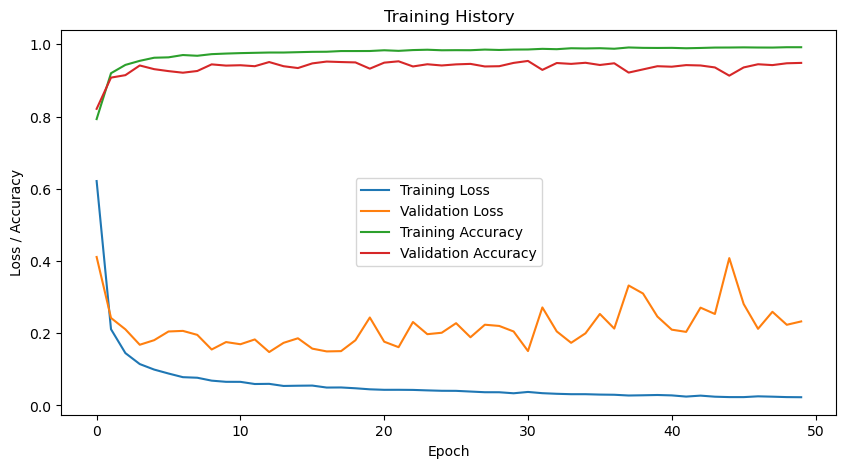

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.title('Training History')
plt.legend()
plt.show()

# tanh,softmax,sgd

In [38]:
model_1 = Sequential()
model_1.add(Dense(16,activation='tanh',input_shape = X_train.shape[1:]))
model_1.add(Dense(32,activation='tanh'))
model_1.add(Dense(6,activation='softmax'))

In [39]:
model_1.compile(loss = 'sparse_categorical_crossentropy',metrics =['accuracy'],optimizer="SGD")

In [40]:
# model_1.fit(X_train,Y_train,epochs=25)
history1 = model_1.fit(X_train,Y_train,epochs=50, validation_data=(X_test, Y_test))

Epoch 1/50
230/230 [==============================] - 1s 3ms/step - loss: 1.1019 - accuracy: 0.6809 - val_loss: 0.7734 - val_accuracy: 0.8100
Epoch 2/50
230/230 [==============================] - 1s 2ms/step - loss: 0.5962 - accuracy: 0.8456 - val_loss: 0.5420 - val_accuracy: 0.8527
Epoch 3/50
230/230 [==============================] - 1s 2ms/step - loss: 0.4302 - accuracy: 0.8840 - val_loss: 0.4421 - val_accuracy: 0.8748
Epoch 4/50
230/230 [==============================] - 1s 3ms/step - loss: 0.3414 - accuracy: 0.8985 - val_loss: 0.3436 - val_accuracy: 0.9013
Epoch 5/50
230/230 [==============================] - 1s 3ms/step - loss: 0.2876 - accuracy: 0.9108 - val_loss: 0.3078 - val_accuracy: 0.9091
Epoch 6/50
230/230 [==============================] - 1s 3ms/step - loss: 0.2486 - accuracy: 0.9219 - val_loss: 0.2680 - val_accuracy: 0.9050
Epoch 7/50
230/230 [==============================] - 1s 2ms/step - loss: 0.2212 - accuracy: 0.9267 - val_loss: 0.2543 - val_accuracy: 0.9237
Epoch 

In [41]:
model_1.evaluate(X_test,Y_test)

93/93 [==============================] - 0s 2ms/step - loss: 0.1305 - accuracy: 0.9542


[0.1304662674665451, 0.954190731048584]

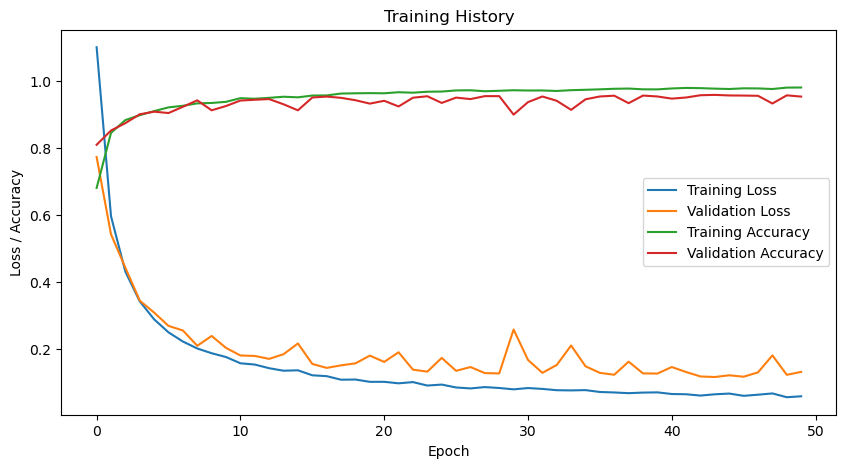

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.title('Training History')
plt.legend()
plt.show()

# relu,softmax,sgd

In [43]:
model_2 = Sequential()
model_2.add(Dense(16,activation='relu',input_shape = X_train.shape[1:]))
model_2.add(Dense(32,activation='relu'))
model_2.add(Dense(6,activation='softmax'))

In [44]:
model_2.compile(loss = 'sparse_categorical_crossentropy',metrics =['accuracy'],optimizer="SGD")

In [45]:
# model_2.fit(X_train,Y_train,epochs=25)
history2 = model_2.fit(X_train,Y_train,epochs=50, validation_data=(X_test, Y_test))

Epoch 1/50
230/230 [==============================] - 1s 4ms/step - loss: 1.3024 - accuracy: 0.4716 - val_loss: 0.9303 - val_accuracy: 0.7075
Epoch 2/50
230/230 [==============================] - 1s 2ms/step - loss: 0.6908 - accuracy: 0.7350 - val_loss: 0.6085 - val_accuracy: 0.7323
Epoch 3/50
230/230 [==============================] - 1s 3ms/step - loss: 0.4779 - accuracy: 0.8234 - val_loss: 0.4213 - val_accuracy: 0.8656
Epoch 4/50
230/230 [==============================] - 1s 3ms/step - loss: 0.3569 - accuracy: 0.8693 - val_loss: 0.3236 - val_accuracy: 0.8836
Epoch 5/50
230/230 [==============================] - 1s 3ms/step - loss: 0.2905 - accuracy: 0.8919 - val_loss: 0.3143 - val_accuracy: 0.8717
Epoch 6/50
230/230 [==============================] - 1s 3ms/step - loss: 0.2517 - accuracy: 0.9053 - val_loss: 0.2990 - val_accuracy: 0.8728
Epoch 7/50
230/230 [==============================] - 1s 3ms/step - loss: 0.2233 - accuracy: 0.9162 - val_loss: 0.2957 - val_accuracy: 0.8585
Epoch 

In [46]:
model_2.evaluate(X_test,Y_test)

93/93 [==============================] - 0s 2ms/step - loss: 0.1267 - accuracy: 0.9552


[0.12671059370040894, 0.9552086591720581]

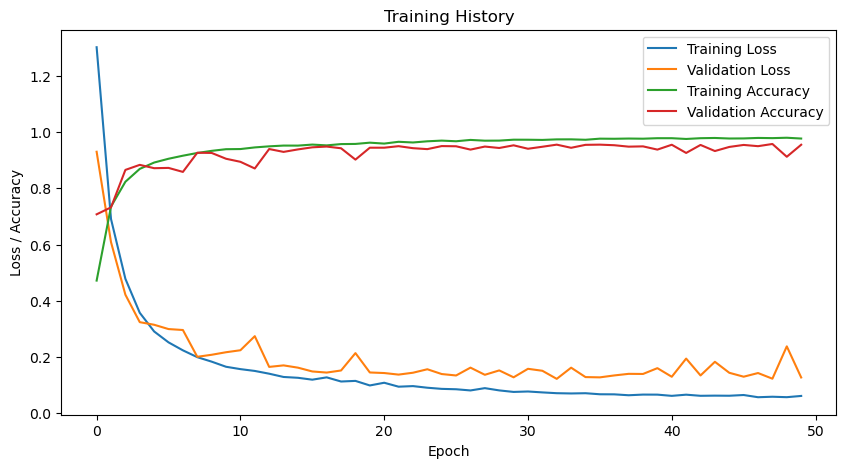

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.title('Training History')
plt.legend()
plt.show()

# relu,softmax,rmsprop

In [48]:
model_3 = Sequential()
model_3.add(Dense(16,activation='relu',input_shape = X_train.shape[1:]))
model_3.add(Dense(32,activation='relu'))
model_3.add(Dense(6,activation='softmax'))

In [49]:
model_3.compile(loss = 'sparse_categorical_crossentropy',metrics =['accuracy'],optimizer="rmsprop")

In [50]:
# model_3.fit(X_train,Y_train,epochs=25)
model_3.fit(X_train,Y_train,epochs=50)

Epoch 1/50
230/230 [==============================] - 1s 2ms/step - loss: 0.6601 - accuracy: 0.7573
Epoch 2/50
230/230 [==============================] - 0s 2ms/step - loss: 0.2411 - accuracy: 0.9052
Epoch 3/50
230/230 [==============================] - 0s 2ms/step - loss: 0.1666 - accuracy: 0.9361
Epoch 4/50
230/230 [==============================] - 0s 2ms/step - loss: 0.1342 - accuracy: 0.9495
Epoch 5/50
230/230 [==============================] - 0s 2ms/step - loss: 0.1096 - accuracy: 0.9555
Epoch 6/50
230/230 [==============================] - 0s 2ms/step - loss: 0.0994 - accuracy: 0.9606
Epoch 7/50
230/230 [==============================] - 0s 2ms/step - loss: 0.0901 - accuracy: 0.9630
Epoch 8/50
230/230 [==============================] - 0s 2ms/step - loss: 0.0806 - accuracy: 0.9693
Epoch 9/50
230/230 [==============================] - 0s 2ms/step - loss: 0.0744 - accuracy: 0.9706
Epoch 10/50
230/230 [==============================] - 0s 2ms/step - loss: 0.0718 - accuracy: 0.9721

In [51]:
model_3.evaluate(X_test,Y_test)

93/93 [==============================] - 0s 2ms/step - loss: 0.2479 - accuracy: 0.9420


[0.24790428578853607, 0.9419748783111572]

# relu,softmax,adam

In [52]:
model_3.compile(loss = 'sparse_categorical_crossentropy',metrics =['accuracy'],optimizer="adam")

In [53]:
# model_3.fit(X_train,Y_train,epochs=25)
history3 = model_3.fit(X_train,Y_train,epochs=50, validation_data=(X_test, Y_test))

Epoch 1/50
230/230 [==============================] - 2s 3ms/step - loss: 0.0252 - accuracy: 0.9899 - val_loss: 0.3172 - val_accuracy: 0.9410
Epoch 2/50
230/230 [==============================] - 1s 3ms/step - loss: 0.0339 - accuracy: 0.9867 - val_loss: 0.3959 - val_accuracy: 0.9328
Epoch 3/50
230/230 [==============================] - 1s 2ms/step - loss: 0.0256 - accuracy: 0.9899 - val_loss: 0.3003 - val_accuracy: 0.9471
Epoch 4/50
230/230 [==============================] - 1s 2ms/step - loss: 0.0210 - accuracy: 0.9921 - val_loss: 0.3124 - val_accuracy: 0.9365
Epoch 5/50
230/230 [==============================] - 1s 2ms/step - loss: 0.0240 - accuracy: 0.9912 - val_loss: 0.2515 - val_accuracy: 0.9498
Epoch 6/50
230/230 [==============================] - 1s 2ms/step - loss: 0.0225 - accuracy: 0.9916 - val_loss: 0.6664 - val_accuracy: 0.8972
Epoch 7/50
230/230 [==============================] - 1s 2ms/step - loss: 0.0275 - accuracy: 0.9895 - val_loss: 0.2379 - val_accuracy: 0.9474
Epoch 

In [54]:
model_3.evaluate(X_test,Y_test)

93/93 [==============================] - 0s 2ms/step - loss: 0.3429 - accuracy: 0.9437


[0.3429136276245117, 0.9436715245246887]

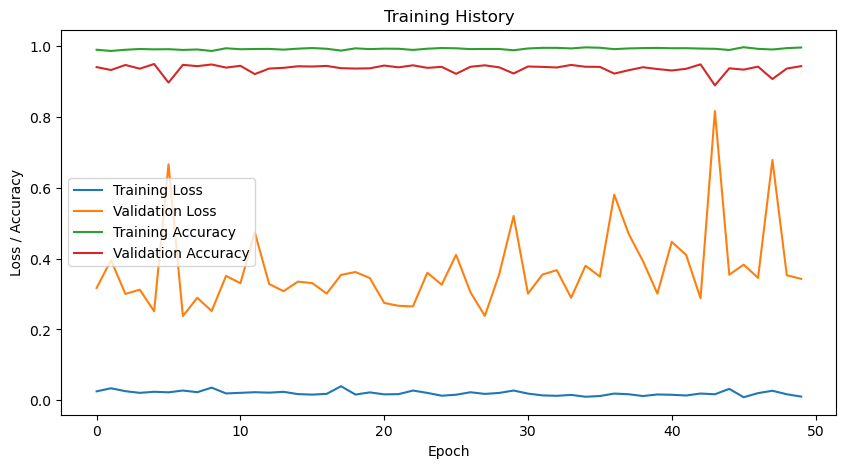

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.plot(history3.history['accuracy'], label='Training Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.title('Training History')
plt.legend()
plt.show()